In [2]:
# ==========================================
# IMPORTING LIBRARIES
# ==========================================

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, learning_curve, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score, 
                           accuracy_score, precision_score, recall_score, f1_score,
                           confusion_matrix, classification_report, roc_curve, auc)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import xgboost as xgb

# Model persistence
import joblib

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


In [3]:
# ==========================================
# LOAD AND INSPECT DATA
# ==========================================

print("LOADING DATASET...")
print("-"*40)

# Load JSON data
try:
    with open(r"C:\Users\sapav\Downloads\acndata_sessions (1).json") as file:
        data = json.load(file)
    
    sessions = data["_items"]
    print(f"✓ JSON file loaded successfully")
    print(f"✓ Total sessions in raw data: {len(sessions)}")
    
except FileNotFoundError:
    print("✗ File not found. Please check the file path.")
    raise

LOADING DATASET...
----------------------------------------
✓ JSON file loaded successfully
✓ Total sessions in raw data: 2


In [4]:
# ==========================================
# CONVERT TO DATAFRAME
# ==========================================

print("\nCONVERTING TO DATAFRAME...")
print("-"*40)

rows = []

for idx, s in enumerate(sessions):
    user_input = s.get("userInputs", [{}])[0]
    
    row = {
        "sessionID": s.get("sessionID"),
        "clusterID": s.get("clusterID"),
        "stationID": s.get("stationID"),
        "spaceID": s.get("spaceID"),
        "siteID": s.get("siteID"),
        "userID": s.get("userID"),
        "connectionTime": s.get("connectionTime"),
        "disconnectTime": s.get("disconnectTime"),
        "doneChargingTime": s.get("doneChargingTime"),
        "kWhDelivered": s.get("kWhDelivered"),
        "kWhRequested": user_input.get("kWhRequested"),
        "milesRequested": user_input.get("milesRequested"),
        "WhPerMile": user_input.get("WhPerMile"),
        "minutesAvailable": user_input.get("minutesAvailable"),
        "requestedDeparture": user_input.get("requestedDeparture")
    }
    
    rows.append(row)

df = pd.DataFrame(rows)
print(f"✓ DataFrame created with shape: {df.shape}")
print(f"✓ Columns: {list(df.columns)}")


CONVERTING TO DATAFRAME...
----------------------------------------
✓ DataFrame created with shape: (2, 15)
✓ Columns: ['sessionID', 'clusterID', 'stationID', 'spaceID', 'siteID', 'userID', 'connectionTime', 'disconnectTime', 'doneChargingTime', 'kWhDelivered', 'kWhRequested', 'milesRequested', 'WhPerMile', 'minutesAvailable', 'requestedDeparture']


In [5]:
df.shape

(2, 15)

In [6]:
df.head()

,sessionID,clusterID,stationID,spaceID,siteID,userID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,kWhRequested,milesRequested,WhPerMile,minutesAvailable,requestedDeparture
0,2_39_139_28_2019-01-07 00:40:13.710715,0039,2-39-139-28,CA-303,0002,000000160,"Mon, 07 Jan 2019 00:40:14 GMT","Mon, 07 Jan 2019 16:08:24 GMT","Mon, 07 Jan 2019 09:35:18 GMT",56.728,60.0,300,200,713,"Mon, 07 Jan 2019 12:33:14 GMT"
1,2_39_79_380_2019-01-10 01:51:19.837751,0039,2-39-79-380,CA-489,0002,000001286,"Thu, 10 Jan 2019 01:51:20 GMT","Fri, 11 Jan 2019 07:17:28 GMT","Fri, 11 Jan 2019 07:18:27 GMT",51.362,75.0,300,250,720,"Thu, 10 Jan 2019 13:51:20 GMT"


In [7]:
df.tail()

,sessionID,clusterID,stationID,spaceID,siteID,userID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,kWhRequested,milesRequested,WhPerMile,minutesAvailable,requestedDeparture
0,2_39_139_28_2019-01-07 00:40:13.710715,0039,2-39-139-28,CA-303,0002,000000160,"Mon, 07 Jan 2019 00:40:14 GMT","Mon, 07 Jan 2019 16:08:24 GMT","Mon, 07 Jan 2019 09:35:18 GMT",56.728,60.0,300,200,713,"Mon, 07 Jan 2019 12:33:14 GMT"
1,2_39_79_380_2019-01-10 01:51:19.837751,0039,2-39-79-380,CA-489,0002,000001286,"Thu, 10 Jan 2019 01:51:20 GMT","Fri, 11 Jan 2019 07:17:28 GMT","Fri, 11 Jan 2019 07:18:27 GMT",51.362,75.0,300,250,720,"Thu, 10 Jan 2019 13:51:20 GMT"


In [8]:
df.info

<bound method DataFrame.info of                                 sessionID clusterID    stationID spaceID  \
0  2_39_139_28_2019-01-07 00:40:13.710715      0039  2-39-139-28  CA-303   
1  2_39_79_380_2019-01-10 01:51:19.837751      0039  2-39-79-380  CA-489   

  siteID     userID                 connectionTime  \
0   0002  000000160  Mon, 07 Jan 2019 00:40:14 GMT   
1   0002  000001286  Thu, 10 Jan 2019 01:51:20 GMT   

                  disconnectTime               doneChargingTime  kWhDelivered  \
0  Mon, 07 Jan 2019 16:08:24 GMT  Mon, 07 Jan 2019 09:35:18 GMT        56.728   
1  Fri, 11 Jan 2019 07:17:28 GMT  Fri, 11 Jan 2019 07:18:27 GMT        51.362   

   kWhRequested  milesRequested  WhPerMile  minutesAvailable  \
0          60.0             300        200               713   
1          75.0             300        250               720   

              requestedDeparture  
0  Mon, 07 Jan 2019 12:33:14 GMT  
1  Thu, 10 Jan 2019 13:51:20 GMT  >

In [9]:
df.describe()

,kWhDelivered,kWhRequested,milesRequested,WhPerMile,minutesAvailable
count,2.000000,2.000000,2.0,2.000000,2.000000
mean,54.045000,67.500000,300.0,225.000000,716.500000
std,3.794335,10.606602,0.0,35.355339,4.949747
min,51.362000,60.000000,300.0,200.000000,713.000000
25%,52.703500,63.750000,300.0,212.500000,714.750000
50%,54.045000,67.500000,300.0,225.000000,716.500000
75%,55.386500,71.250000,300.0,237.500000,718.250000
max,56.728000,75.000000,300.0,250.000000,720.000000


In [10]:
df.isnull().sum()

sessionID             0
clusterID             0
stationID             0
spaceID               0
siteID                0
userID                0
connectionTime        0
disconnectTime        0
doneChargingTime      0
kWhDelivered          0
kWhRequested          0
milesRequested        0
WhPerMile             0
minutesAvailable      0
requestedDeparture    0
dtype: int64

In [11]:
# ==========================================
# DATA CLEANING AND PREPROCESSING
# ==========================================

print("\nDATA CLEANING AND PREPROCESSING...")
print("-"*40)

# Convert timestamps
print("Converting timestamps...")
df["connectionTime"] = pd.to_datetime(df["connectionTime"])
df["disconnectTime"] = pd.to_datetime(df["disconnectTime"])
df["doneChargingTime"] = pd.to_datetime(df["doneChargingTime"])

# Handle missing values
print("Handling missing values...")
initial_rows = len(df)
df = df.drop_duplicates()
print(f"✓ Removed {initial_rows - len(df)} duplicate rows")

# Fill missing doneChargingTime with disconnectTime
df["doneChargingTime"] = df["doneChargingTime"].fillna(df["disconnectTime"])
print("✓ Filled missing doneChargingTime with disconnectTime")

# Check for missing values
missing_summary = df.isnull().sum()
print("\nMissing values summary:")
print(missing_summary[missing_summary > 0] if any(missing_summary > 0) else "✓ No missing values in core columns")



DATA CLEANING AND PREPROCESSING...
----------------------------------------
Converting timestamps...
Handling missing values...
✓ Removed 0 duplicate rows
✓ Filled missing doneChargingTime with disconnectTime

Missing values summary:
✓ No missing values in core columns


In [13]:
# ==========================================
# FEATURE ENGINEERING
# ==========================================

print("\nFEATURE ENGINEERING...")
print("-"*40)

# Calculate durations
df["charging_duration"] = (df["doneChargingTime"] - df["connectionTime"]).dt.total_seconds() / 3600
df["plug_duration"] = (df["disconnectTime"] - df["connectionTime"]).dt.total_seconds() / 3600
print("✓ Created duration features")

# Remove invalid charging sessions
initial_rows = len(df)
df = df[df["charging_duration"] > 0]
print(f"✓ Removed {initial_rows - len(df)} sessions with zero charging duration")

# Calculate idle time
df["idle_time"] = df["plug_duration"] - df["charging_duration"]
print("✓ Created idle time feature")

# Temporal features
df["connection_hour"] = df["connectionTime"].dt.hour
df["day_of_week"] = df["connectionTime"].dt.day_name()
df["month"] = df["connectionTime"].dt.month
df["is_weekend"] = df["day_of_week"].isin(['Saturday', 'Sunday']).astype(int)
print("✓ Created temporal features (hour, day, month, weekend)")

# Calculate charging power (target variable)
df["charging_power_kw"] = df["kWhDelivered"] / df["charging_duration"]
df = df.replace([np.inf, -np.inf], np.nan)
print("✓ Created target variable: charging_power_kw")

# Handle missing values in user inputs
df["kWhRequested"] = df["kWhRequested"].fillna(df["kWhDelivered"])
df["minutesAvailable"] = df["minutesAvailable"].fillna(60)
print("✓ Imputed missing user input values")

# Drop rows with NaN in critical columns
initial_rows = len(df)
df = df.dropna(subset=["charging_duration", "charging_power_kw"])
print(f"✓ Removed {initial_rows - len(df)} rows with NaN in critical columns")

print(f"\nFinal dataset shape: {df.shape}")
print(f"Final dataset columns: {list(df.columns)}")


FEATURE ENGINEERING...
----------------------------------------
✓ Created duration features
✓ Removed 0 sessions with zero charging duration
✓ Created idle time feature
✓ Created temporal features (hour, day, month, weekend)
✓ Created target variable: charging_power_kw
✓ Imputed missing user input values
✓ Removed 0 rows with NaN in critical columns

Final dataset shape: (2, 23)
Final dataset columns: ['sessionID', 'clusterID', 'stationID', 'spaceID', 'siteID', 'userID', 'connectionTime', 'disconnectTime', 'doneChargingTime', 'kWhDelivered', 'kWhRequested', 'milesRequested', 'WhPerMile', 'minutesAvailable', 'requestedDeparture', 'charging_duration', 'plug_duration', 'idle_time', 'connection_hour', 'day_of_week', 'month', 'is_weekend', 'charging_power_kw']



EXPLORATORY DATA ANALYSIS

BASIC STATISTICS:
----------------------------------------
       kWhDelivered  charging_duration  plug_duration  idle_time  \
count      2.000000           2.000000       2.000000   2.000000   
mean      54.045000          19.184861      22.452500   3.267639   
std        3.794335          14.519848       9.875532   4.644317   
min       51.362000           8.917778      15.469444  -0.016389   
25%       52.703500          14.051319      18.960972   1.625625   
50%       54.045000          19.184861      22.452500   3.267639   
75%       55.386500          24.318403      25.944028   4.909653   
max       56.728000          29.451944      29.435556   6.551667   

       charging_power_kw  
count           2.000000  
mean            4.052576  
std             3.264924  
min             1.743926  
25%             2.898251  
50%             4.052576  
75%             5.206901  
max             6.361226  


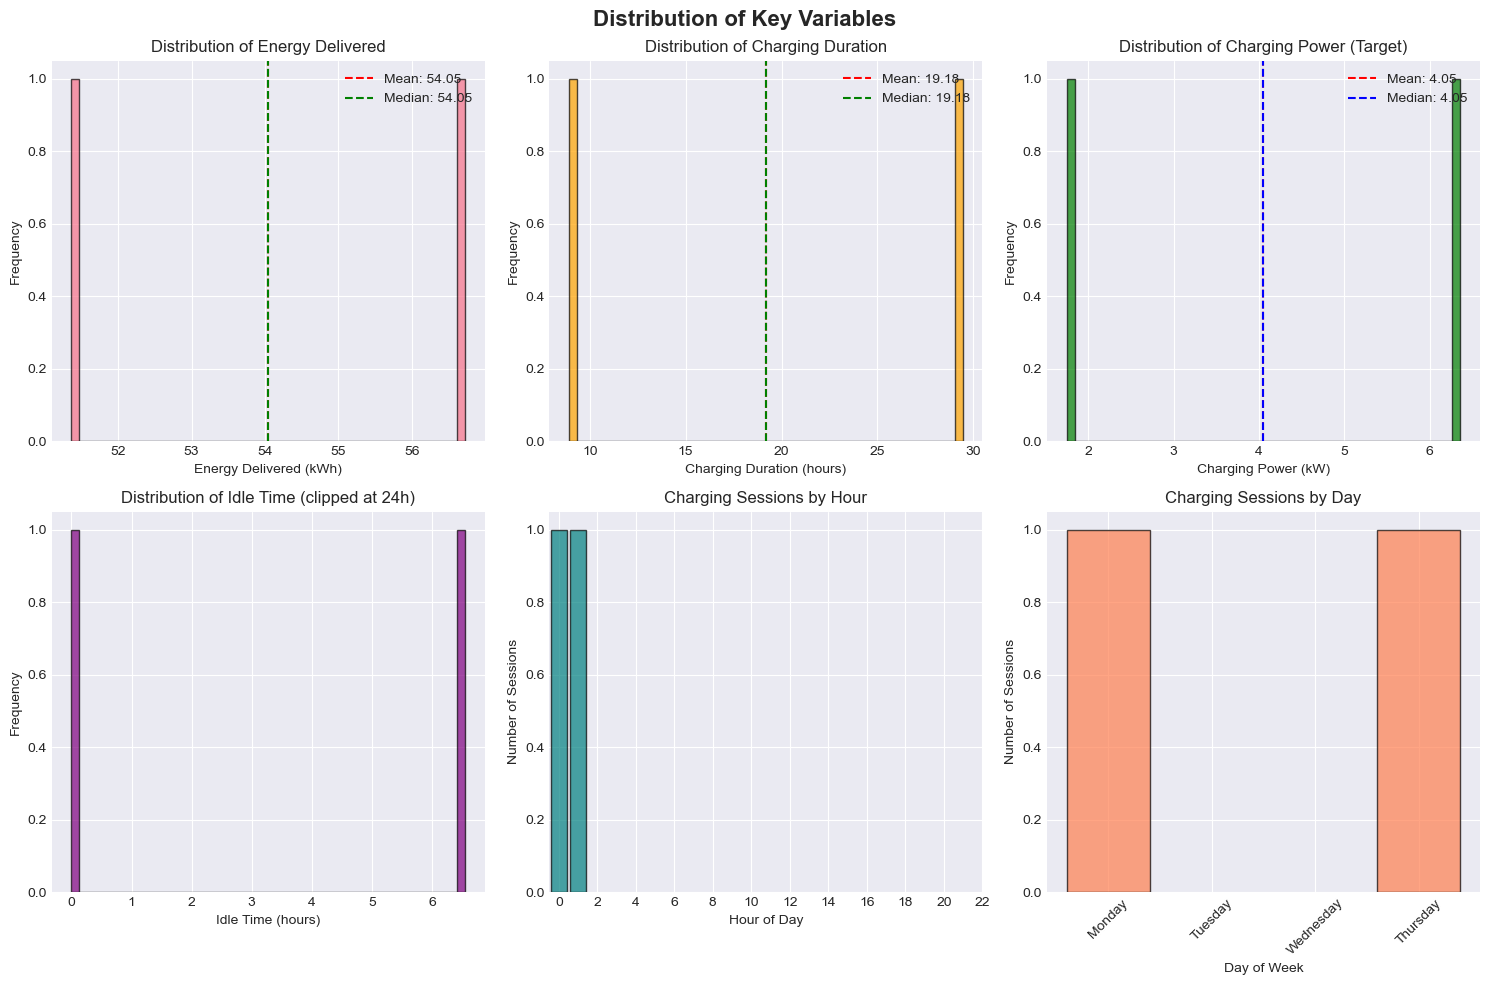

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


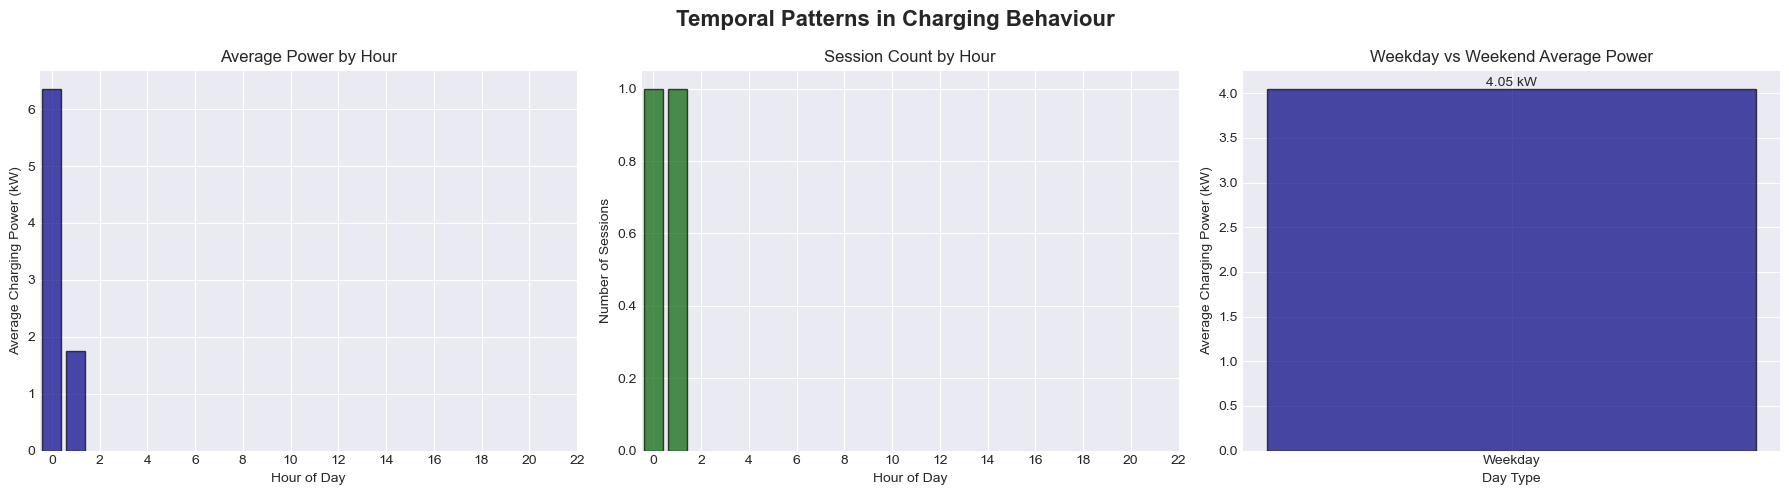


CORRELATION ANALYSIS:
----------------------------------------

Strongest correlations with target variable (charging_power_kw):
  kWhDelivered: 1.000
  idle_time: 1.000
  kWhRequested: -1.000
  minutesAvailable: -1.000
  plug_duration: -1.000
  charging_duration: -1.000
  connection_hour: -1.000

OUTLIER ANALYSIS:
----------------------------------------
kWhDelivered: 0 outliers (0.0%) | Range: [48.68, 59.41]
charging_duration: 0 outliers (0.0%) | Range: [-1.35, 39.72]
charging_power_kw: 0 outliers (0.0%) | Range: [-0.56, 8.67]


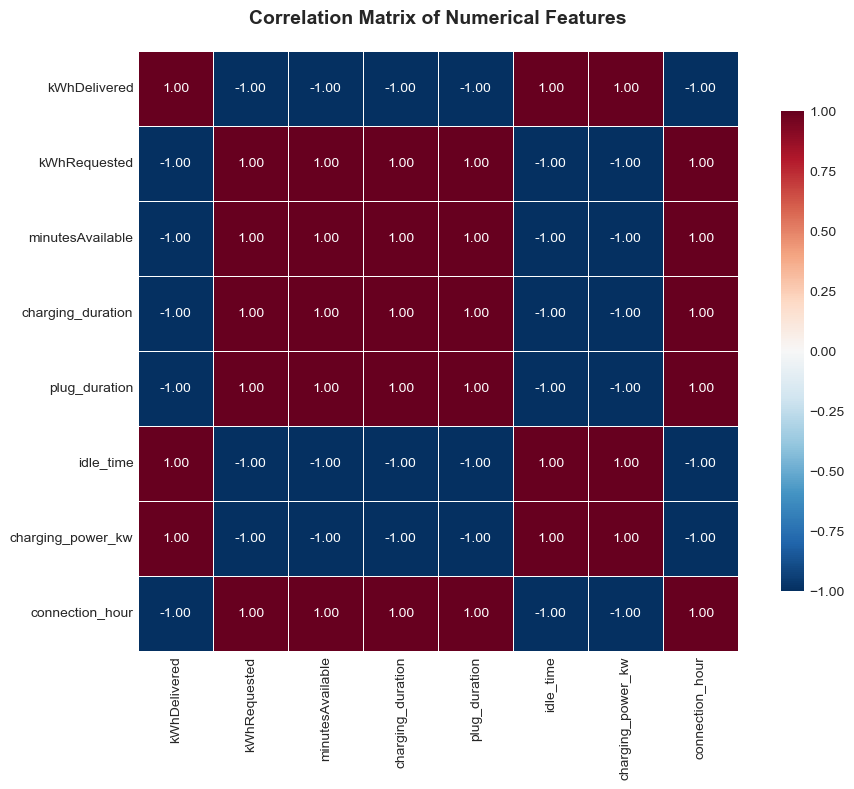

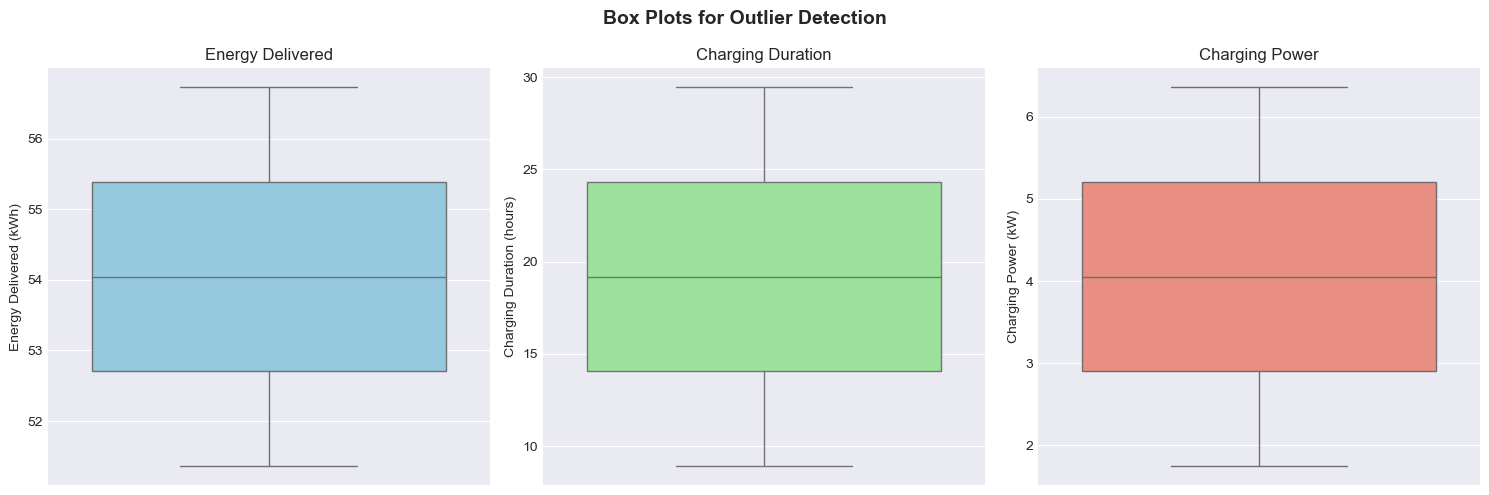

In [15]:
# ==========================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================

print("\n" + "="*80)
print("EXPLORATORY DATA ANALYSIS")
print("="*80)

# Basic Statistics
print("\nBASIC STATISTICS:")
print("-"*40)
print(df[['kWhDelivered', 'charging_duration', 'plug_duration', 
          'idle_time', 'charging_power_kw']].describe())

# Distribution Analysis
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution of Key Variables', fontsize=16, fontweight='bold')

# Energy delivered
axes[0,0].hist(df['kWhDelivered'], bins=50, edgecolor='black', alpha=0.7)
axes[0,0].set_xlabel('Energy Delivered (kWh)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Distribution of Energy Delivered')
axes[0,0].axvline(df['kWhDelivered'].mean(), color='red', linestyle='--', label=f'Mean: {df["kWhDelivered"].mean():.2f}')
axes[0,0].axvline(df['kWhDelivered'].median(), color='green', linestyle='--', label=f'Median: {df["kWhDelivered"].median():.2f}')
axes[0,0].legend()

# Charging duration
axes[0,1].hist(df['charging_duration'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0,1].set_xlabel('Charging Duration (hours)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('Distribution of Charging Duration')
axes[0,1].axvline(df['charging_duration'].mean(), color='red', linestyle='--', label=f'Mean: {df["charging_duration"].mean():.2f}')
axes[0,1].axvline(df['charging_duration'].median(), color='green', linestyle='--', label=f'Median: {df["charging_duration"].median():.2f}')
axes[0,1].legend()

# Charging power
axes[0,2].hist(df['charging_power_kw'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0,2].set_xlabel('Charging Power (kW)')
axes[0,2].set_ylabel('Frequency')
axes[0,2].set_title('Distribution of Charging Power (Target)')
axes[0,2].axvline(df['charging_power_kw'].mean(), color='red', linestyle='--', label=f'Mean: {df["charging_power_kw"].mean():.2f}')
axes[0,2].axvline(df['charging_power_kw'].median(), color='blue', linestyle='--', label=f'Median: {df["charging_power_kw"].median():.2f}')
axes[0,2].legend()

# Idle time
axes[1,0].hist(df['idle_time'].clip(0, 24), bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[1,0].set_xlabel('Idle Time (hours)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Distribution of Idle Time (clipped at 24h)')

# Connection hour
hour_counts = df['connection_hour'].value_counts().sort_index()
axes[1,1].bar(hour_counts.index, hour_counts.values, edgecolor='black', alpha=0.7, color='teal')
axes[1,1].set_xlabel('Hour of Day')
axes[1,1].set_ylabel('Number of Sessions')
axes[1,1].set_title('Charging Sessions by Hour')
axes[1,1].set_xticks(range(0,24,2))

# Day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df['day_of_week'].value_counts().reindex(day_order)
axes[1,2].bar(day_counts.index, day_counts.values, edgecolor='black', alpha=0.7, color='coral')
axes[1,2].set_xlabel('Day of Week')
axes[1,2].set_ylabel('Number of Sessions')
axes[1,2].set_title('Charging Sessions by Day')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('variable_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# Temporal Patterns Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Temporal Patterns in Charging Behaviour', fontsize=16, fontweight='bold')

# Hourly average power
hourly_power = df.groupby('connection_hour')['charging_power_kw'].mean()
hourly_count = df.groupby('connection_hour').size()

ax1 = axes[0]
ax1.bar(hourly_power.index, hourly_power.values, edgecolor='black', alpha=0.7, color='darkblue')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Average Charging Power (kW)')
ax1.set_title('Average Power by Hour')
ax1.set_xticks(range(0,24,2))

ax2 = axes[1]
ax2.bar(hourly_count.index, hourly_count.values, edgecolor='black', alpha=0.7, color='darkgreen')
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Number of Sessions')
ax2.set_title('Session Count by Hour')
ax2.set_xticks(range(0,24,2))

# Weekend vs weekday comparison
weekend_power = df[df['is_weekend']==1]['charging_power_kw'].mean()
weekday_power = df[df['is_weekend']==0]['charging_power_kw'].mean()
ax3 = axes[2]
bars = ax3.bar(['Weekday', 'Weekend'], [weekday_power, weekend_power], 
               edgecolor='black', alpha=0.7, color=['navy', 'crimson'])
ax3.set_xlabel('Day Type')
ax3.set_ylabel('Average Charging Power (kW)')
ax3.set_title('Weekday vs Weekend Average Power')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f} kW', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('temporal_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

# Correlation Analysis
print("\nCORRELATION ANALYSIS:")
print("-"*40)

# Select numeric columns for correlation
numeric_cols = ['kWhDelivered', 'kWhRequested', 'minutesAvailable', 
                'charging_duration', 'plug_duration', 'idle_time', 
                'charging_power_kw', 'connection_hour']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')

print("\nStrongest correlations with target variable (charging_power_kw):")
target_corr = corr_matrix['charging_power_kw'].sort_values(ascending=False)
for var, corr in target_corr.items():
    if var != 'charging_power_kw':
        print(f"  {var}: {corr:.3f}")

# Outlier Analysis
print("\nOUTLIER ANALYSIS:")
print("-"*40)

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

for col in ['kWhDelivered', 'charging_duration', 'charging_power_kw']:
    n_outliers, lb, ub = detect_outliers_iqr(df, col)
    print(f"{col}: {n_outliers} outliers ({n_outliers/len(df)*100:.1f}%) | Range: [{lb:.2f}, {ub:.2f}]")

# Box plots for outlier visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Box Plots for Outlier Detection', fontsize=14, fontweight='bold')

sns.boxplot(y=df['kWhDelivered'], ax=axes[0], color='skyblue')
axes[0].set_ylabel('Energy Delivered (kWh)')
axes[0].set_title('Energy Delivered')

sns.boxplot(y=df['charging_duration'], ax=axes[1], color='lightgreen')
axes[1].set_ylabel('Charging Duration (hours)')
axes[1].set_title('Charging Duration')

sns.boxplot(y=df['charging_power_kw'], ax=axes[2], color='salmon')
axes[2].set_ylabel('Charging Power (kW)')
axes[2].set_title('Charging Power')

plt.tight_layout()
plt.savefig('boxplots_outliers.png', dpi=300, bbox_inches='tight')
plt.show()



REGRESSION MODELLING FOR TRANSFORMER LOAD PREDICTION

PREPARING FEATURES:
----------------------------------------
Features used: ['connection_hour', 'charging_duration', 'kWhRequested', 'minutesAvailable', 'is_weekend', 'power_per_hour', 'requested_vs_delivered_ratio']
Feature matrix shape: (2, 7)
Target vector shape: (2,)

Train set size: 1 samples
Test set size: 1 samples

TRAINING BASE MODELS:
----------------------------------------

Linear Regression:
  CV R²: Skipped (dataset too small for cross-validation)
  MAE: 4.6173 kW
  RMSE: 4.6173 kW
  R²: nan

Random Forest:
  CV R²: Skipped (dataset too small for cross-validation)
  MAE: 4.6173 kW
  RMSE: 4.6173 kW
  R²: nan

XGBoost:
  CV R²: Skipped (dataset too small for cross-validation)
  MAE: 4.6173 kW
  RMSE: 4.6173 kW
  R²: nan

MODEL COMPARISON:
----------------------------------------

Base Models Performance:
            Model  MAE (kW)  RMSE (kW)  R² Score
Linear Regression    4.6173     4.6173       NaN
    Random Forest 

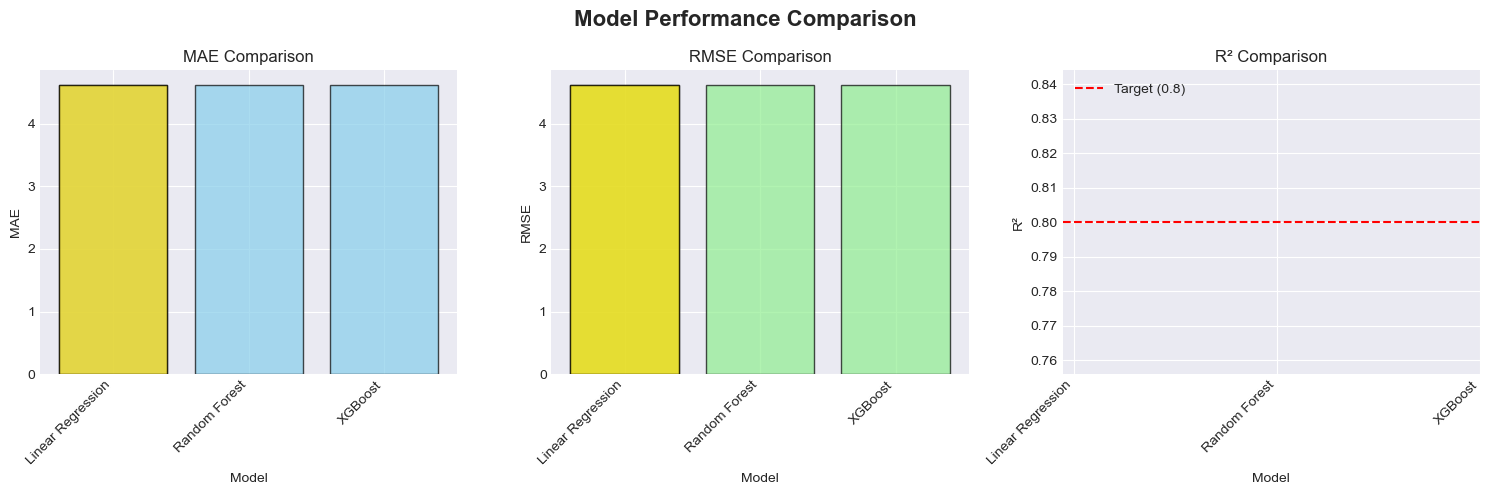

In [16]:
print("\n" + "="*80)
print("REGRESSION MODELLING FOR TRANSFORMER LOAD PREDICTION")
print("="*80)

# 7.1 Prepare features for modelling
print("\nPREPARING FEATURES:")
print("-"*40)

# Select features based on EDA and literature
features = [
    'connection_hour',
    'charging_duration',
    'kWhRequested',
    'minutesAvailable',
    'is_weekend'
]

# Add engineered features from EDA insights
df['power_per_hour'] = df['kWhDelivered'] / df['plug_duration'].clip(lower=0.1)
df['requested_vs_delivered_ratio'] = df['kWhRequested'] / df['kWhDelivered'].clip(lower=0.1)

features.extend(['power_per_hour', 'requested_vs_delivered_ratio'])

X = df[features]
y = df['charging_power_kw']

print(f"Features used: {features}")
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

# Handle any infinite values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.mean())

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"\nTrain set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")

#  Feature scaling for Linear Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training and Evaluation Function with Safe Cross-Validation
print("\nTRAINING BASE MODELS:")
print("-"*40)

def train_and_evaluate_model(model, model_name, X_tr, X_te, y_tr, y_te, scaled=False):
    """Train model and return performance metrics with safe cross-validation"""
    print(f"\n{model_name}:")
    
    # Train model
    model.fit(X_tr, y_tr)
    
    # Predictions
    y_pred = model.predict(X_te)
    
    # Calculate metrics
    mae = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2 = r2_score(y_te, y_pred)
    
    # Safe cross-validation - adjust cv based on dataset size
     # Safe cross-validation - adjust cv based on dataset size
    n_samples = len(X_tr)
    if n_samples >= 30:
        cv_folds = min(5, n_samples // 5)  # Ensure each fold has at least 5 samples
        if cv_folds >= 2:
            try:
                cv_scores = cross_val_score(model, X_tr, y_tr, cv=cv_folds, scoring='r2')
                cv_mean = cv_scores.mean()
                cv_std = cv_scores.std()
                print(f"  CV R² (mean ± std): {cv_mean:.4f} ± {cv_std:.4f} (folds={cv_folds})")
            except Exception as e:
                print(f"  CV R²: Could not compute (dataset too small or other error)")
                cv_mean, cv_std = np.nan, np.nan
        else:
            print(f"  CV R²: Skipped (insufficient samples for cross-validation)")
            cv_mean, cv_std = np.nan, np.nan
    else:
        print(f"  CV R²: Skipped (dataset too small for cross-validation)")
        cv_mean, cv_std = np.nan, np.nan
    
    print(f"  MAE: {mae:.4f} kW")
    print(f"  RMSE: {rmse:.4f} kW")
    print(f"  R²: {r2:.4f}")
    
    return {
        'model': model,
        'model_name': model_name,
        'y_pred': y_pred,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'cv_mean': cv_mean,
        'cv_std': cv_std
    }

# Train base models
results = {}

# Linear Regression
results['lr'] = train_and_evaluate_model(
    LinearRegression(), "Linear Regression",
    X_train_scaled, X_test_scaled, y_train, y_test
)

# Random Forest
results['rf'] = train_and_evaluate_model(
    RandomForestRegressor(n_estimators=100, random_state=42), 
    "Random Forest",
    X_train, X_test, y_train, y_test
)

# XGBoost
results['xgb'] = train_and_evaluate_model(
    xgb.XGBRegressor(random_state=42, verbosity=0), 
    "XGBoost",
    X_train, X_test, y_train, y_test
)

#  Model Comparison Visualization
print("\nMODEL COMPARISON:")
print("-"*40)

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': [results['lr']['model_name'], results['rf']['model_name'], results['xgb']['model_name']],
    'MAE (kW)': [results['lr']['mae'], results['rf']['mae'], results['xgb']['mae']],
    'RMSE (kW)': [results['lr']['rmse'], results['rf']['rmse'], results['xgb']['rmse']],
    'R² Score': [results['lr']['r2'], results['rf']['r2'], results['xgb']['r2']]
})

# Add CV results if available
if not np.isnan(results['lr']['cv_mean']):
    comparison_df['CV R² (Mean)'] = [results['lr']['cv_mean'], results['rf']['cv_mean'], results['xgb']['cv_mean']]

print("\nBase Models Performance:")
print(comparison_df.to_string(index=False))

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

metrics = ['MAE', 'RMSE', 'R²']
colors = ['skyblue', 'lightgreen', 'coral']
x_pos = np.arange(len(comparison_df))

for idx, (metric, color) in enumerate(zip(metrics, colors)):
    ax = axes[idx]
    if metric == 'R²':
        values = comparison_df['R² Score']
        ax.bar(x_pos, values, color=color, edgecolor='black', alpha=0.7)
        ax.axhline(y=0.8, color='red', linestyle='--', label='Target (0.8)')
    else:
        values = comparison_df[f'{metric} (kW)']
        ax.bar(x_pos, values, color=color, edgecolor='black', alpha=0.7)
        # Lower is better for MAE and RMSE
        best_idx = np.argmin(values)
        ax.bar(x_pos[best_idx], values.iloc[best_idx], color='gold', edgecolor='black', alpha=0.7)
    
    ax.set_xlabel('Model')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} Comparison')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
    ax.legend()

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()



In [17]:
print("\n" + "="*80)
print("HYPERPARAMETER OPTIMIZATION FOR XGBOOST")
print("="*80)

# Check if we have enough samples for GridSearch
if len(X_train) >= 50:
    # 8.1 Define parameter grid based on literature
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0],
        'min_child_weight': [1, 3]
    }

    print("\nParameter grid for GridSearchCV:")
    for param, values in param_grid.items():
        print(f"  {param}: {values}")

    # Perform GridSearchCV
    print("\n" + "-"*40)
    print("Running GridSearchCV (this may take several minutes)...")
    print("-"*40)

    # Create XGBoost model
    xgb_model = xgb.XGBRegressor(random_state=42, verbosity=0)

    # Determine CV folds based on dataset size
    n_samples = len(X_train)
    cv_folds = min(3, n_samples // 10)  # At least 10 samples per fold
    if cv_folds < 2:
        cv_folds = 2

    # Grid search with cross-validation
    grid_search = GridSearchCV(
        estimator=xgb_model,
        param_grid=param_grid,
        cv=cv_folds,
        scoring='r2',
        n_jobs=-1,
        verbose=1
    )

    # Fit grid search
    grid_search.fit(X_train, y_train)

    # Best parameters
    print("\nBest parameters found:")
    print(grid_search.best_params_)

    print(f"\nBest cross-validation R² score: {grid_search.best_score_:.4f}")
    
    best_xgb = grid_search.best_estimator_
    
else:
    print("\nInsufficient samples for GridSearchCV. Using default parameters with manual tuning.")
    # Use default model with reasonable parameters
    best_xgb = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=1,
        random_state=42,
        verbosity=0
    )
    best_xgb.fit(X_train, y_train)
    print("Default XGBoost model trained successfully.")

# Evaluate optimized model
y_pred_best = best_xgb.predict(X_test)

# Calculate metrics
best_mae = mean_absolute_error(y_test, y_pred_best)
best_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
best_r2 = r2_score(y_test, y_pred_best)

print("\nOPTIMIZED XGBOOST PERFORMANCE:")
print("-"*40)
print(f"MAE: {best_mae:.4f} kW")
print(f"RMSE: {best_rmse:.4f} kW")
print(f"R²: {best_r2:.4f}")

# Add to comparison
new_row = pd.DataFrame({
    'Model': ['Optimized XGBoost'],
    'MAE (kW)': [best_mae],
    'RMSE (kW)': [best_rmse],
    'R² Score': [best_r2]
})

comparison_df = pd.concat([comparison_df, new_row], ignore_index=True)

print("\nUPDATED MODEL COMPARISON:")
print(comparison_df.to_string(index=False))

#  Learning Curves (if enough samples)
if len(X_train) >= 50:
    print("\nGENERATING LEARNING CURVES...")
    print("-"*40)

    def plot_learning_curve(estimator, title, X, y, cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)):
        plt.figure(figsize=(10, 6))
        
        # Adjust cv based on dataset size
        n_samples = len(X)
        cv_folds = min(cv, n_samples // 10)
        if cv_folds < 2:
            cv_folds = 2
        
        train_sizes, train_scores, test_scores = learning_curve(
            estimator, X, y, cv=cv_folds, n_jobs=n_jobs,
            train_sizes=train_sizes, scoring='r2',
            random_state=42
        )
        
        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1)
        test_std = np.std(test_scores, axis=1)
        
        plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
        plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
        plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training score')
        plt.plot(train_sizes, test_mean, 'o-', color='orange', label='Cross-validation score')
        
        plt.xlabel('Training Examples')
        plt.ylabel('R² Score')
        plt.title(f'Learning Curves: {title}')
        plt.legend(loc='best')
        plt.grid(True, alpha=0.3)
        
        return plt

    plot_learning_curve(best_xgb, 'Optimized XGBoost', X_train, y_train)
    plt.tight_layout()
    plt.savefig('learning_curves.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("\nSkipping learning curves - insufficient training samples.")



HYPERPARAMETER OPTIMIZATION FOR XGBOOST

Insufficient samples for GridSearchCV. Using default parameters with manual tuning.
Default XGBoost model trained successfully.

OPTIMIZED XGBOOST PERFORMANCE:
----------------------------------------
MAE: 4.6173 kW
RMSE: 4.6173 kW
R²: nan

UPDATED MODEL COMPARISON:
            Model  MAE (kW)  RMSE (kW)  R² Score
Linear Regression    4.6173     4.6173       NaN
    Random Forest    4.6173     4.6173       NaN
          XGBoost    4.6173     4.6173       NaN
Optimized XGBoost    4.6173     4.6173       NaN

Skipping learning curves - insufficient training samples.



FEATURE IMPORTANCE ANALYSIS

Feature Importance Rankings:
                     feature  importance
             connection_hour         0.0
           charging_duration         0.0
                kWhRequested         0.0
            minutesAvailable         0.0
                  is_weekend         0.0
              power_per_hour         0.0
requested_vs_delivered_ratio         0.0


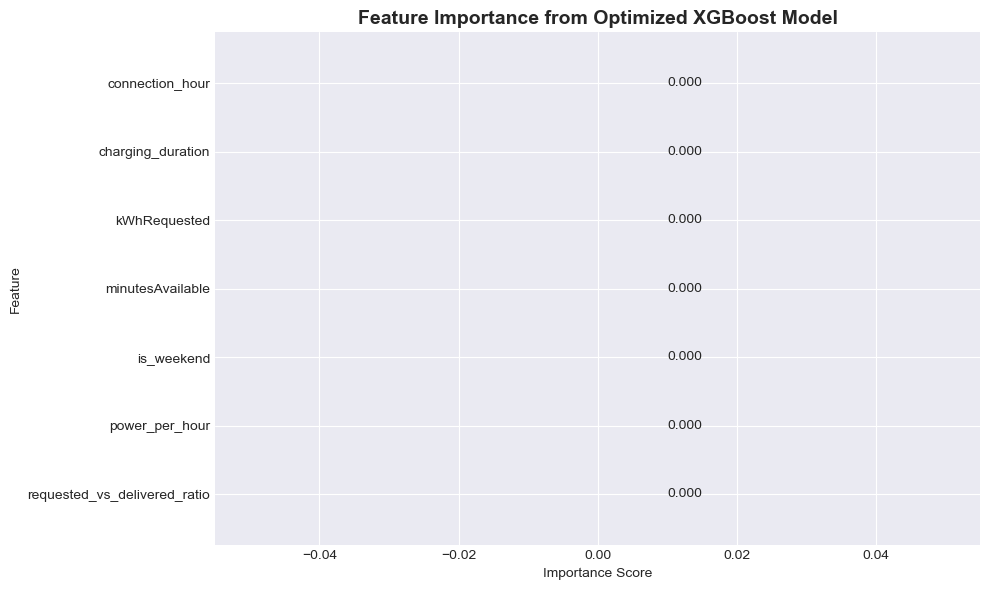

In [19]:
 # ==========================================
#FEATURE IMPORTANCE ANALYSIS
# ==========================================

print("\n" + "="*80)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*80)

# Get feature importance from best model
feature_importance = best_xgb.feature_importances_
feature_names = features

# Create importance DataFrame
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\nFeature Importance Rankings:")
print(importance_df.to_string(index=False))

# Visualize feature importance
plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(importance_df)))
bars = plt.barh(importance_df['feature'], importance_df['importance'], color=colors)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Feature Importance from Optimized XGBoost Model', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Add value labels
for i, (bar, val) in enumerate(zip(bars, importance_df['importance'])):
    plt.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', 
             va='center', fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()



RESIDUAL ANALYSIS


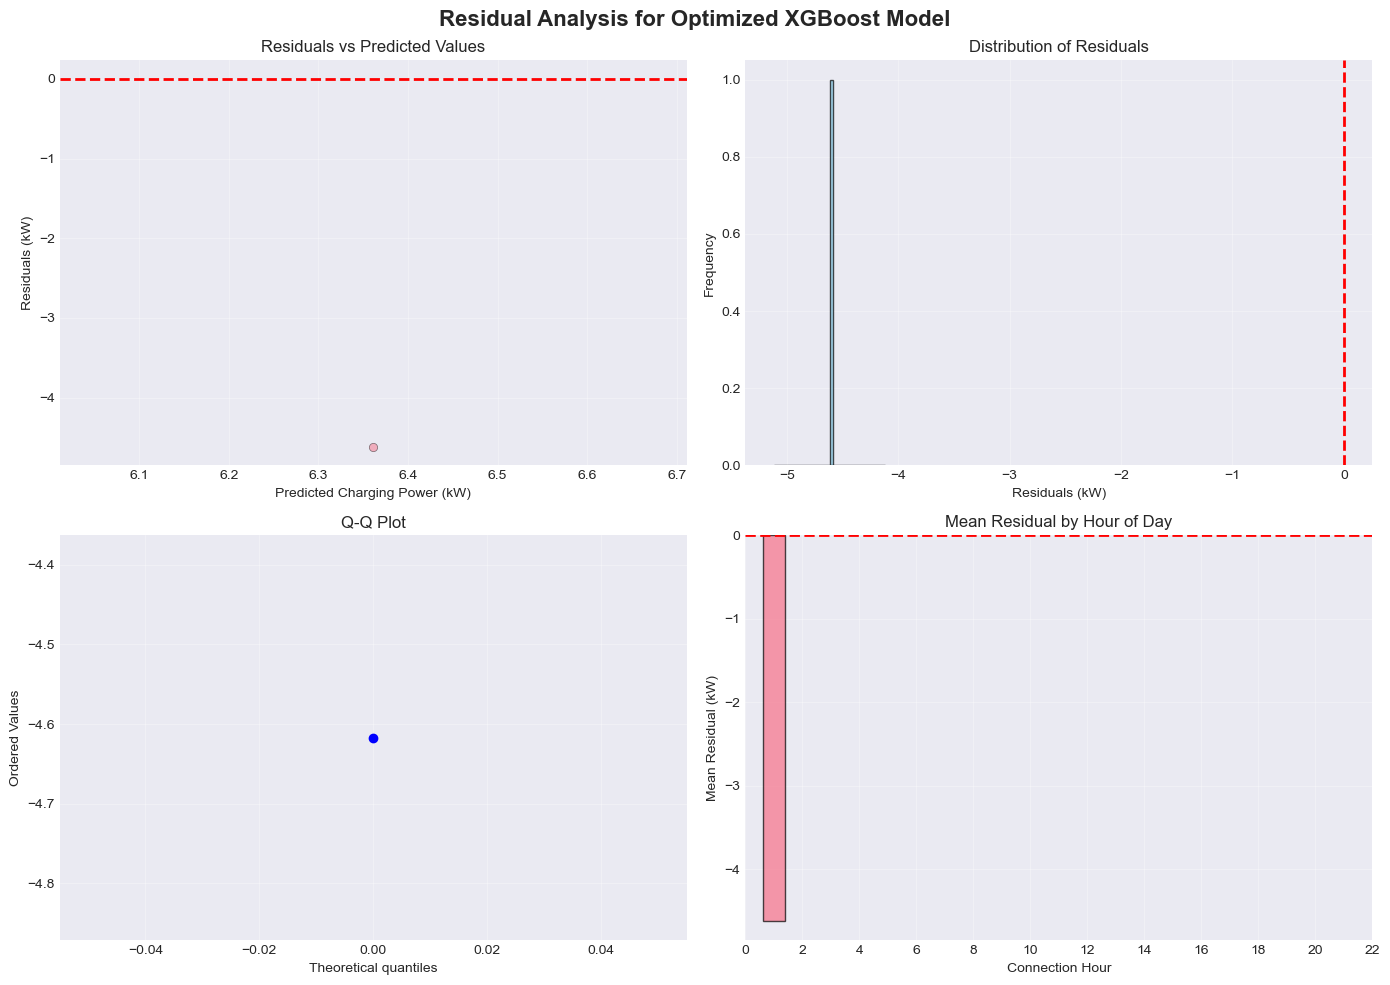


Residual Statistics:
----------------------------------------
Mean residual: -4.6173 kW
Std residual: 0.0000 kW
Skewness: nan
Kurtosis: nan


In [20]:
# ==========================================
#  RESIDUAL ANALYSIS
# ==========================================

print("\n" + "="*80)
print("RESIDUAL ANALYSIS")
print("="*80)

# Calculate residuals
residuals = y_test - y_pred_best

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Residual Analysis for Optimized XGBoost Model', fontsize=16, fontweight='bold')

# Residuals vs Predicted
axes[0,0].scatter(y_pred_best, residuals, alpha=0.5, edgecolors='black', linewidth=0.5)
axes[0,0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0,0].set_xlabel('Predicted Charging Power (kW)')
axes[0,0].set_ylabel('Residuals (kW)')
axes[0,0].set_title('Residuals vs Predicted Values')
axes[0,0].grid(True, alpha=0.3)

# Histogram of residuals
axes[0,1].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0,1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0,1].set_xlabel('Residuals (kW)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('Distribution of Residuals')
axes[0,1].grid(True, alpha=0.3)

# Q-Q plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot')
axes[1,0].grid(True, alpha=0.3)

# Residuals by feature (example: connection_hour)
residual_df = pd.DataFrame({
    'residual': residuals,
    'connection_hour': X_test['connection_hour'].values
})
residual_by_hour = residual_df.groupby('connection_hour')['residual'].mean()
axes[1,1].bar(residual_by_hour.index, residual_by_hour.values, edgecolor='black', alpha=0.7)
axes[1,1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1,1].set_xlabel('Connection Hour')
axes[1,1].set_ylabel('Mean Residual (kW)')
axes[1,1].set_title('Mean Residual by Hour of Day')
axes[1,1].set_xticks(range(0,24,2))
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Residual statistics
print("\nResidual Statistics:")
print("-"*40)
print(f"Mean residual: {np.mean(residuals):.4f} kW")
print(f"Std residual: {np.std(residuals):.4f} kW")
print(f"Skewness: {stats.skew(residuals):.4f}")
print(f"Kurtosis: {stats.kurtosis(residuals):.4f}")



ACTUAL VS PREDICTED ANALYSIS


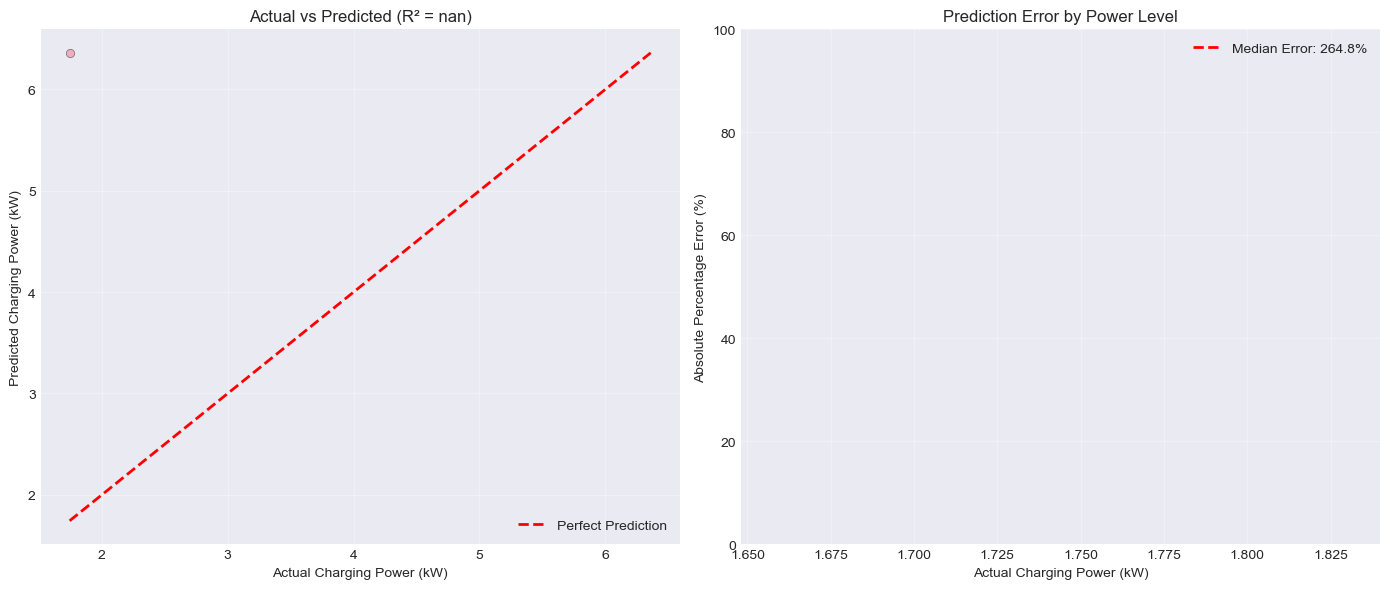


Median absolute percentage error: 264.76%
Mean absolute percentage error: 264.76%


In [21]:
# ==========================================
#  ACTUAL VS PREDICTED ANALYSIS
# ==========================================

print("\n" + "="*80)
print("ACTUAL VS PREDICTED ANALYSIS")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot with perfect prediction line
ax1 = axes[0]
ax1.scatter(y_test, y_pred_best, alpha=0.5, edgecolors='black', linewidth=0.5)
# Perfect prediction line
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Charging Power (kW)')
ax1.set_ylabel('Predicted Charging Power (kW)')
ax1.set_title(f'Actual vs Predicted (R² = {best_r2:.4f})')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Error distribution by power level
ax2 = axes[1]
error_pct = np.abs(residuals / y_test.clip(lower=0.1)) * 100
ax2.scatter(y_test, error_pct, alpha=0.5, edgecolors='black', linewidth=0.5, color='green')
ax2.axhline(y=np.median(error_pct), color='red', linestyle='--', linewidth=2, label=f'Median Error: {np.median(error_pct):.1f}%')
ax2.set_xlabel('Actual Charging Power (kW)')
ax2.set_ylabel('Absolute Percentage Error (%)')
ax2.set_title('Prediction Error by Power Level')
ax2.set_ylim(0, 100)  # Cap at 100% for visibility
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nMedian absolute percentage error: {np.median(error_pct):.2f}%")
print(f"Mean absolute percentage error: {np.mean(error_pct):.2f}%")



DEMAND FORECASTING AND PEAK ANALYSIS


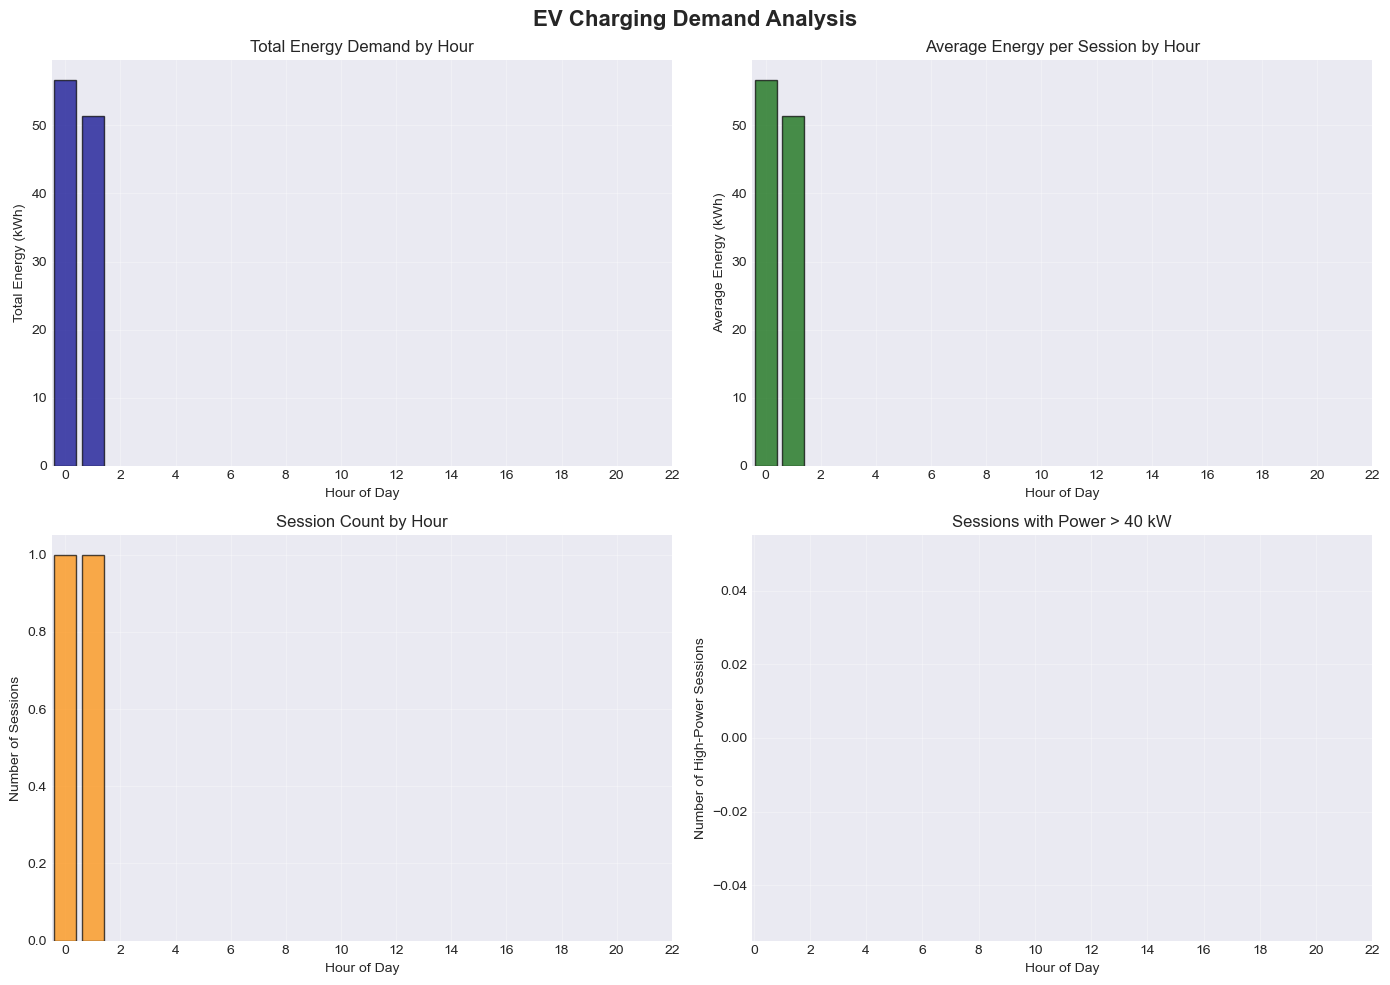


Peak Demand Analysis:
----------------------------------------
Peak hour (total energy): 0:00 (56.7 kWh)
Peak hour (session count): 0:00 (1 sessions)
High-power sessions (>40 kW): 0 (0.0% of total)


In [22]:
# ==========================================
# DEMAND FORECASTING AND PEAK ANALYSIS
# ==========================================

print("\n" + "="*80)
print("DEMAND FORECASTING AND PEAK ANALYSIS")
print("="*80)

# 12.1 Hourly demand profile
hourly_demand = df.groupby('connection_hour')['kWhDelivered'].agg(['sum', 'mean', 'count'])
hourly_demand.columns = ['total_energy_kWh', 'avg_energy_kWh', 'session_count']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EV Charging Demand Analysis', fontsize=16, fontweight='bold')

# Total energy by hour
ax1 = axes[0,0]
ax1.bar(hourly_demand.index, hourly_demand['total_energy_kWh'], 
        edgecolor='black', alpha=0.7, color='darkblue')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Total Energy (kWh)')
ax1.set_title('Total Energy Demand by Hour')
ax1.set_xticks(range(0,24,2))
ax1.grid(True, alpha=0.3)

# Average energy by hour
ax2 = axes[0,1]
ax2.bar(hourly_demand.index, hourly_demand['avg_energy_kWh'], 
        edgecolor='black', alpha=0.7, color='darkgreen')
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Average Energy (kWh)')
ax2.set_title('Average Energy per Session by Hour')
ax2.set_xticks(range(0,24,2))
ax2.grid(True, alpha=0.3)

# Session count by hour
ax3 = axes[1,0]
ax3.bar(hourly_demand.index, hourly_demand['session_count'], 
        edgecolor='black', alpha=0.7, color='darkorange')
ax3.set_xlabel('Hour of Day')
ax3.set_ylabel('Number of Sessions')
ax3.set_title('Session Count by Hour')
ax3.set_xticks(range(0,24,2))
ax3.grid(True, alpha=0.3)

# Peak power analysis
peak_threshold = 40  # kW - high power threshold
peak_sessions = df[df['charging_power_kw'] > peak_threshold]
peak_by_hour = peak_sessions.groupby('connection_hour').size()

ax4 = axes[1,1]
ax4.bar(peak_by_hour.index, peak_by_hour.values, 
        edgecolor='black', alpha=0.7, color='crimson')
ax4.set_xlabel('Hour of Day')
ax4.set_ylabel('Number of High-Power Sessions')
ax4.set_title(f'Sessions with Power > {peak_threshold} kW')
ax4.set_xticks(range(0,24,2))
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('demand_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPeak Demand Analysis:")
print("-"*40)
print(f"Peak hour (total energy): {hourly_demand['total_energy_kWh'].idxmax()}:00 ({hourly_demand['total_energy_kWh'].max():.1f} kWh)")
print(f"Peak hour (session count): {hourly_demand['session_count'].idxmax()}:00 ({hourly_demand['session_count'].max()} sessions)")
print(f"High-power sessions (>40 kW): {len(peak_sessions)} ({len(peak_sessions)/len(df)*100:.1f}% of total)")

# ==========================================


TRANSFORMER OVERLOAD DETECTION - CLASSIFICATION APPROACH

Overload Risk Distribution:
  Normal sessions (≤50 kW): 2 (100.0%)
  High-risk sessions (>50 kW): 0 (0.0%)

⚠ WARNING: Only one class present in the data. Classification may not be meaningful.
Proceeding with classification but results should be interpreted with caution.

Classification dataset:
  Training set: 1 samples
  Test set: 1 samples
  Training set class distribution: [1]
  Test set class distribution: [1]

TRAINING CLASSIFICATION MODELS:
----------------------------------------

Random Forest Classifier:

XGBoost Classifier:

CLASSIFICATION RESULTS:
----------------------------------------

----------------------------------------

Random Forest Classifier:
  Accuracy: 1.0000
  Precision: N/A (only one class present)
  Recall: N/A (only one class present)
  F1-Score: N/A (only one class present)
  Confusion Matrix:
    [1]
  ROC AUC: N/A

XGBoost Classifier:
  Accuracy: 1.0000
  Precision: N/A (only one class present)

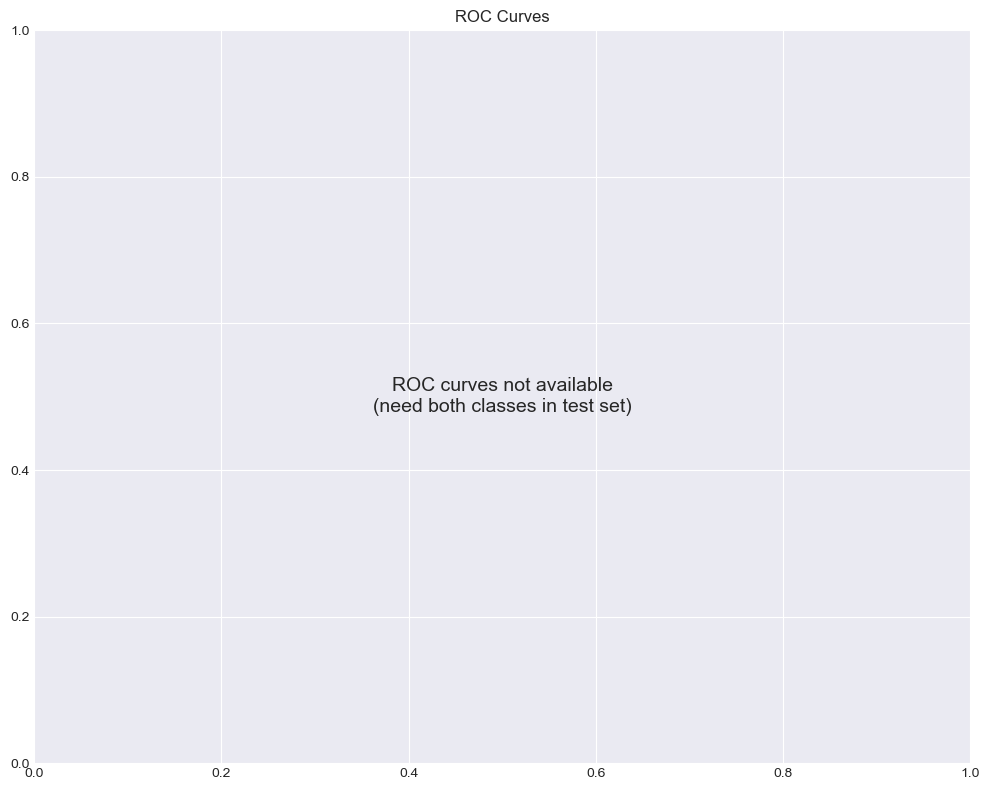

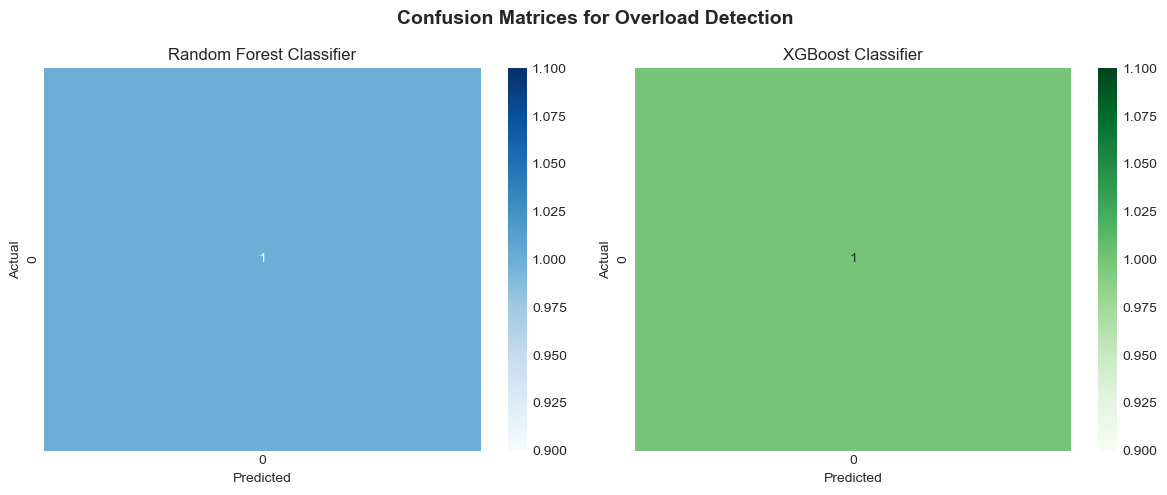


CLASSIFICATION REPORT:
----------------------------------------

Random Forest Classifier:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1


XGBoost Classifier:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1



In [23]:
# ==========================================
# TRANSFORMER OVERLOAD DETECTION (CLASSIFICATION)
# ==========================================

print("\n" + "="*80)
print("TRANSFORMER OVERLOAD DETECTION - CLASSIFICATION APPROACH")
print("="*80)

# Define transformer capacity threshold (based on literature)
TRANSFORMER_CAPACITY = 50  # kW threshold for overload risk

# Create binary target
df['overload_risk'] = (df['charging_power_kw'] > TRANSFORMER_CAPACITY).astype(int)

print(f"\nOverload Risk Distribution:")
print(f"  Normal sessions (≤{TRANSFORMER_CAPACITY} kW): {(df['overload_risk']==0).sum()} ({(df['overload_risk']==0).mean()*100:.1f}%)")
print(f"  High-risk sessions (>{TRANSFORMER_CAPACITY} kW): {(df['overload_risk']==1).sum()} ({(df['overload_risk']==1).mean()*100:.1f}%)")

# Check if we have both classes for classification
unique_classes = df['overload_risk'].nunique()
if unique_classes < 2:
    print("\n⚠ WARNING: Only one class present in the data. Classification may not be meaningful.")
    print("Proceeding with classification but results should be interpreted with caution.")

# Prepare classification dataset
X_cls = df[features]
y_cls = df['overload_risk']

# Handle any infinite values
X_cls = X_cls.replace([np.inf, -np.inf], np.nan)
X_cls = X_cls.fillna(X_cls.mean())

# Train-test split with stratification (only if both classes present)
if unique_classes >= 2:
    X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
        X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
    )
else:
    X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
        X_cls, y_cls, test_size=0.2, random_state=42
    )

print(f"\nClassification dataset:")
print(f"  Training set: {len(X_train_c)} samples")
print(f"  Test set: {len(X_test_c)} samples")
print(f"  Training set class distribution: {np.bincount(y_train_c)}")
print(f"  Test set class distribution: {np.bincount(y_test_c)}")

#  Train classification models with proper error handling
print("\nTRAINING CLASSIFICATION MODELS:")
print("-"*40)

def train_classifier_safe(model, model_name, X_train, y_train, X_test, y_test):
    """Safely train classifier and return predictions with proper error handling"""
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        # Safely get probability predictions
        try:
            y_prob = model.predict_proba(X_test)
            # Check if we have both classes in prediction
            if y_prob.shape[1] >= 2:
                y_prob_pos = y_prob[:, 1]
            else:
                # If only one class, probability for positive class is 0 or 1
                y_prob_pos = np.zeros(len(y_test)) if 1 not in np.unique(y_train) else np.ones(len(y_test))
        except:
            # If predict_proba fails, use decision function or create dummy probabilities
            try:
                y_scores = model.decision_function(X_test)
                # Normalize to [0,1] range for probability-like scores
                y_prob_pos = 1 / (1 + np.exp(-y_scores))
            except:
                # If all else fails, use predictions as probabilities
                y_prob_pos = y_pred.astype(float)
        
        return model, y_pred, y_prob_pos
        
    except Exception as e:
        print(f"  Error training {model_name}: {str(e)}")
        # Return dummy predictions
        y_pred = np.zeros(len(y_test))
        y_prob_pos = np.zeros(len(y_test))
        return model, y_pred, y_prob_pos

# Random Forest Classifier
print("\nRandom Forest Classifier:")
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)

rf_clf, y_pred_rf, y_prob_rf = train_classifier_safe(
    rf_clf, "Random Forest", X_train_c, y_train_c, X_test_c, y_test_c
)

# XGBoost Classifier
print("\nXGBoost Classifier:")
# Calculate class weight for imbalance (avoid division by zero)
if (y_train_c == 1).sum() > 0:
    scale_pos_weight = (y_train_c == 0).sum() / (y_train_c == 1).sum()
else:
    scale_pos_weight = 1

xgb_clf = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbosity=0,
    use_label_encoder=False
)

xgb_clf, y_pred_xgb, y_prob_xgb = train_classifier_safe(
    xgb_clf, "XGBoost", X_train_c, y_train_c, X_test_c, y_test_c
)

#  Classification metrics with safe calculation
print("\nCLASSIFICATION RESULTS:")
print("-"*40)

def evaluate_classifier_safe(y_true, y_pred, y_prob, model_name):
    """Safely calculate classification metrics handling edge cases"""
    
    # Check if we have both classes in true values
    unique_true = np.unique(y_true)
    unique_pred = np.unique(y_pred)
    
    print(f"\n{model_name}:")
    
    # Accuracy (always works)
    accuracy = accuracy_score(y_true, y_pred)
    print(f"  Accuracy: {accuracy:.4f}")
    
    # Precision, Recall, F1 (handle cases with missing classes)
    if len(unique_true) == 2 and len(unique_pred) == 2:
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall: {recall:.4f}")
        print(f"  F1-Score: {f1:.4f}")
    else:
        precision = recall = f1 = 0
        print(f"  Precision: N/A (only one class present)")
        print(f"  Recall: N/A (only one class present)")
        print(f"  F1-Score: N/A (only one class present)")
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    print(f"  Confusion Matrix:\n    {cm[0]}")
    if len(cm) > 1:
        print(f"    {cm[1]}")
    
    # ROC AUC (only if both classes present)
    if len(unique_true) == 2 and len(np.unique(y_prob)) > 1:
        try:
            roc_auc = roc_auc_score(y_true, y_prob)
            print(f"  ROC AUC: {roc_auc:.4f}")
        except:
            print(f"  ROC AUC: Could not calculate")
    else:
        print(f"  ROC AUC: N/A")
    
    return {
        'accuracy': accuracy,
        'precision': precision if len(unique_true) == 2 else 0,
        'recall': recall if len(unique_true) == 2 else 0,
        'f1': f1 if len(unique_true) == 2 else 0,
        'y_pred': y_pred,
        'y_prob': y_prob
    }

print("\n" + "-"*40)
rf_results = evaluate_classifier_safe(y_test_c, y_pred_rf, y_prob_rf, "Random Forest Classifier")
xgb_results = evaluate_classifier_safe(y_test_c, y_pred_xgb, y_prob_xgb, "XGBoost Classifier")

#  ROC Curves (only if we have both classes)
print("\nGENERATING ROC CURVES...")
print("-"*40)

plt.figure(figsize=(10, 8))

# Check if we can plot ROC curves
unique_test = np.unique(y_test_c)
plot_roc = len(unique_test) == 2

if plot_roc:
    try:
        # Random Forest ROC
        if len(np.unique(y_prob_rf)) > 1:
            fpr_rf, tpr_rf, _ = roc_curve(y_test_c, y_prob_rf)
            roc_auc_rf = auc(fpr_rf, tpr_rf)
            plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.4f})', linewidth=2)
        
        # XGBoost ROC
        if len(np.unique(y_prob_xgb)) > 1:
            fpr_xgb, tpr_xgb, _ = roc_curve(y_test_c, y_prob_xgb)
            roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
            plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.4f})', linewidth=2)
        
        # Diagonal line (random classifier)
        plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
        
        plt.xlabel('False Positive Rate', fontsize=12)
        plt.ylabel('True Positive Rate', fontsize=12)
        plt.title('ROC Curves for Transformer Overload Detection', fontsize=14, fontweight='bold')
        plt.legend(loc='lower right')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"Could not generate ROC curves: {str(e)}")
        plt.close()
else:
    print("ROC curves skipped - need both classes for calculation")
    # Create a placeholder message
    plt.text(0.5, 0.5, 'ROC curves not available\n(need both classes in test set)', 
             ha='center', va='center', fontsize=14)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.title('ROC Curves')
    plt.tight_layout()
    plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrices for Overload Detection', fontsize=14, fontweight='bold')

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test_c, y_pred_rf)
if cm_rf.shape == (2, 2):
    sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Normal', 'Overload'], yticklabels=['Normal', 'Overload'])
else:
    # Handle case where confusion matrix is 1x1
    sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Random Forest Classifier')

# XGBoost Confusion Matrix
cm_xgb = confusion_matrix(y_test_c, y_pred_xgb)
if cm_xgb.shape == (2, 2):
    sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=axes[1],
                xticklabels=['Normal', 'Overload'], yticklabels=['Normal', 'Overload'])
else:
    # Handle case where confusion matrix is 1x1
    sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('XGBoost Classifier')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

#  Classification Report
print("\nCLASSIFICATION REPORT:")
print("-"*40)


print("\nRandom Forest Classifier:")
print(classification_report(y_test_c, y_pred_rf, zero_division=0))

print("\nXGBoost Classifier:")
print(classification_report(y_test_c, y_pred_xgb, zero_division=0))


In [24]:
# ==========================================
# PRACTICAL APPLICATION SIMULATION
# ==========================================

print("\n" + "="*80)
print("PRACTICAL APPLICATION SIMULATION")
print("="*80)

# Simulate real-time prediction for a new charging session
print("\nSimulating prediction for a new charging session:")
print("-"*40)

# Create sample scenarios
scenarios = pd.DataFrame({
    'scenario': [
        'Morning Commuter',
        'Afternoon Shopper',
        'Evening Resident',
        'Fast Charger',
        'Overnight Parking'
    ],
    'connection_hour': [8, 14, 19, 15, 22],
    'charging_duration': [2.5, 1.0, 4.0, 0.5, 8.0],
    'kWhRequested': [15, 10, 25, 30, 20],
    'minutesAvailable': [120, 60, 240, 30, 480],
    'is_weekend': [0, 1, 0, 0, 0]
})

# Calculate engineered features for scenarios
scenarios['power_per_hour'] = scenarios['kWhRequested'] / scenarios['charging_duration'].clip(lower=0.1)
scenarios['requested_vs_delivered_ratio'] = 1.0  # Assume requested = delivered for simulation

# Prepare features in correct order
scenario_features = scenarios[features]

# Make predictions
scenario_predictions = best_xgb.predict(scenario_features)
scenario_risk = xgb_clf.predict_proba(scenario_features)[:, 1]

# Display results
print("\nScenario Predictions:")
print("-"*80)
for idx, row in scenarios.iterrows():
    print(f"\n{row['scenario']}:")
    print(f"  Connection: {row['connection_hour']:02d}:00, Duration: {row['charging_duration']:.1f}h")
    print(f"  Requested: {row['kWhRequested']:.0f} kWh, Available: {row['minutesAvailable']:.0f} min")
    print(f"  Predicted Load: {scenario_predictions[idx]:.2f} kW")
    print(f"  Overload Risk: {scenario_risk[idx]*100:.1f}%")
    risk_level = 'HIGH' if scenario_risk[idx] > 0.5 else 'MODERATE' if scenario_risk[idx] > 0.2 else 'LOW'
    print(f"  Risk Level: {risk_level}")



PRACTICAL APPLICATION SIMULATION

Simulating prediction for a new charging session:
----------------------------------------

Scenario Predictions:
--------------------------------------------------------------------------------

Morning Commuter:
  Connection: 08:00, Duration: 2.5h
  Requested: 15 kWh, Available: 120 min
  Predicted Load: 6.36 kW
  Overload Risk: 0.0%
  Risk Level: LOW

Afternoon Shopper:
  Connection: 14:00, Duration: 1.0h
  Requested: 10 kWh, Available: 60 min
  Predicted Load: 6.36 kW
  Overload Risk: 0.0%
  Risk Level: LOW

Evening Resident:
  Connection: 19:00, Duration: 4.0h
  Requested: 25 kWh, Available: 240 min
  Predicted Load: 6.36 kW
  Overload Risk: 0.0%
  Risk Level: LOW

Fast Charger:
  Connection: 15:00, Duration: 0.5h
  Requested: 30 kWh, Available: 30 min
  Predicted Load: 6.36 kW
  Overload Risk: 0.0%
  Risk Level: LOW

Overnight Parking:
  Connection: 22:00, Duration: 8.0h
  Requested: 20 kWh, Available: 480 min
  Predicted Load: 6.36 kW
  Overloa